In [1]:
!git clone https://github.com/hani-rahmoune/pharma-safety-lakehouse.git
%cd pharma-safety-lakehouse
!pip install -r requirements.txt

Cloning into 'pharma-safety-lakehouse'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 42 (delta 9), reused 42 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 6.44 MiB | 10.82 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/pharma-safety-lakehouse
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 339.2/339.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.1/117.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.4 MB/s eta

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

raw_path = Path("/content/pharma-safety-lakehouse/data/bronze/openfda_events/year=2024/month=01/events.json")

with open(raw_path) as f:
    raw_data = json.load(f)

print(f"Total records loaded: {len(raw_data)}")
print(f"Type of raw_data: {type(raw_data)}")
print(f"Type of one record: {type(raw_data[0])}")

Total records loaded: 1000
Type of raw_data: <class 'list'>
Type of one record: <class 'dict'>


In [3]:
import pprint
pprint.pprint(raw_data[0])

{'companynumb': 'US-SA-SAC20231226000782',
 'duplicate': '1',
 'fulfillexpeditecriteria': '2',
 'occurcountry': 'US',
 'patient': {'drug': [{'actiondrug': '5',
                       'activesubstance': {'activesubstancename': 'DUPILUMAB'},
                       'drugadditional': '3',
                       'drugadministrationroute': '058',
                       'drugauthorizationnumb': '761055',
                       'drugcharacterization': '1',
                       'drugdosageform': 'Solution for injection',
                       'drugdosagetext': '300 MG, QOW',
                       'drugindication': 'Dermatitis atopic',
                       'drugintervaldosagedefinition': '803',
                       'drugintervaldosageunitnumb': '2',
                       'drugseparatedosagenumb': '1',
                       'drugstartdate': '20230915',
                       'drugstartdateformat': '102',
                       'drugstructuredosagenumb': '300',
                       'dr

In [4]:
all_keys = set()
for record in raw_data:
    all_keys.update(record.keys())

print("Top-level keys found across all records:")
for key in sorted(all_keys):
    count = sum(1 for r in raw_data if key in r)
    pct = count / len(raw_data) * 100
    print(f"  {key:<40} present in {count:>5} records ({pct:.1f}%)")

Top-level keys found across all records:
  authoritynumb                            present in    53 records (5.3%)
  companynumb                              present in   947 records (94.7%)
  duplicate                                present in   471 records (47.1%)
  fulfillexpeditecriteria                  present in  1000 records (100.0%)
  occurcountry                             present in   905 records (90.5%)
  patient                                  present in  1000 records (100.0%)
  primarysource                            present in  1000 records (100.0%)
  primarysourcecountry                     present in   994 records (99.4%)
  receiptdate                              present in  1000 records (100.0%)
  receiptdateformat                        present in  1000 records (100.0%)
  receivedate                              present in  1000 records (100.0%)
  receivedateformat                        present in  1000 records (100.0%)
  receiver                               

In [5]:
records_flat = []
for r in raw_data:
    records_flat.append({
        "safety_report_id":       r.get("safetyreportid"),
        "receive_date_raw":        r.get("receivedate"),
        "serious":                 r.get("serious"),
        "serious_death":           r.get("seriousnessdeath"),
        "serious_hospitalization": r.get("seriousnesshospitalization"),
        "country":                 r.get("primarysourcecountry"),
        "patient_age":             r.get("patient", {}).get("patientonsetage"),
        "patient_sex":             r.get("patient", {}).get("patientsex"),
        "num_drugs":               len(r.get("patient", {}).get("drug", [])),
        "num_reactions":           len(r.get("patient", {}).get("reaction", [])),
    })

df = pd.DataFrame(records_flat)
print(df.shape)
df.head(10)


(1000, 10)


,safety_report_id,receive_date_raw,serious,serious_death,serious_hospitalization,country,patient_age,patient_sex,num_drugs,num_reactions
0,23353582,20240101,2,2,2,US,50,2,8,1
1,23353583,20240101,2,2,2,US,89,1,1,3
2,23353584,20240101,2,2,2,US,None,1,1,1
3,23353585,20240101,1,1,2,CA,None,1,1,6
4,23353586,20240101,2,2,2,US,54,1,2,1
5,23353587,20240101,1,2,2,US,None,1,2,1
6,23353588,20240101,1,1,2,CA,61,1,2,1
7,23353589,20240101,1,2,1,CN,57,2,2,5
8,23353590,20240101,1,1,2,CA,60,2,2,1
9,23353591,20240101,1,1,2,CA,83,1,2,1


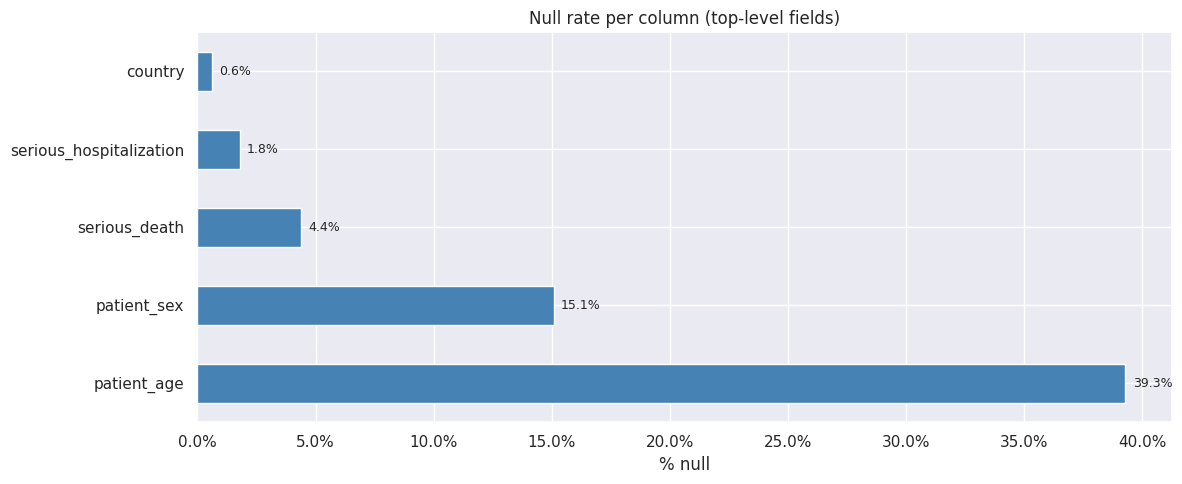

In [6]:
null_rates = df.isnull().mean().sort_values(ascending=False) * 100
null_rates = null_rates[null_rates > 0]

fig, ax = plt.subplots()
null_rates.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% null")
ax.set_title("Null rate per column (top-level fields)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
for bar in ax.patches:
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}%",
        va="center", fontsize=9
    )
plt.tight_layout()
plt.show()

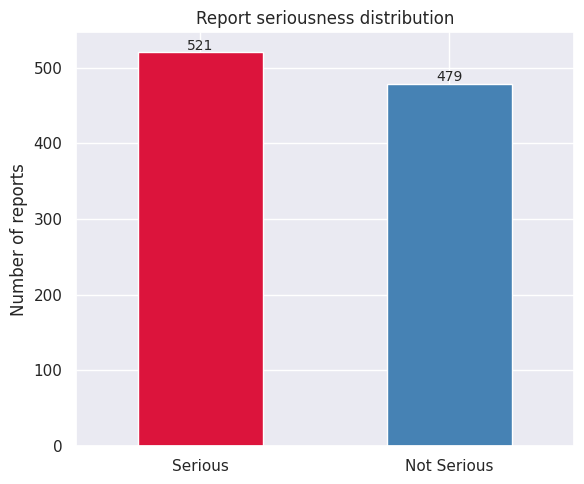


Seriousness rate: 52.1%


In [7]:
serious_counts = df["serious"].value_counts()
labels = {
    "1": "Serious",
    "2": "Not Serious",
    None: "Unknown"
}
serious_counts.index = [labels.get(str(i), str(i)) for i in serious_counts.index]

fig, ax = plt.subplots(figsize=(6, 5))
serious_counts.plot(kind="bar", ax=ax, color=["crimson", "steelblue", "grey"])
ax.set_title("Report seriousness distribution")
ax.set_ylabel("Number of reports")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        str(int(bar.get_height())),
        ha="center", fontsize=10
    )
plt.tight_layout()
plt.show()

print(f"\nSeriousness rate: {(df['serious'] == '1').mean() * 100:.1f}%")

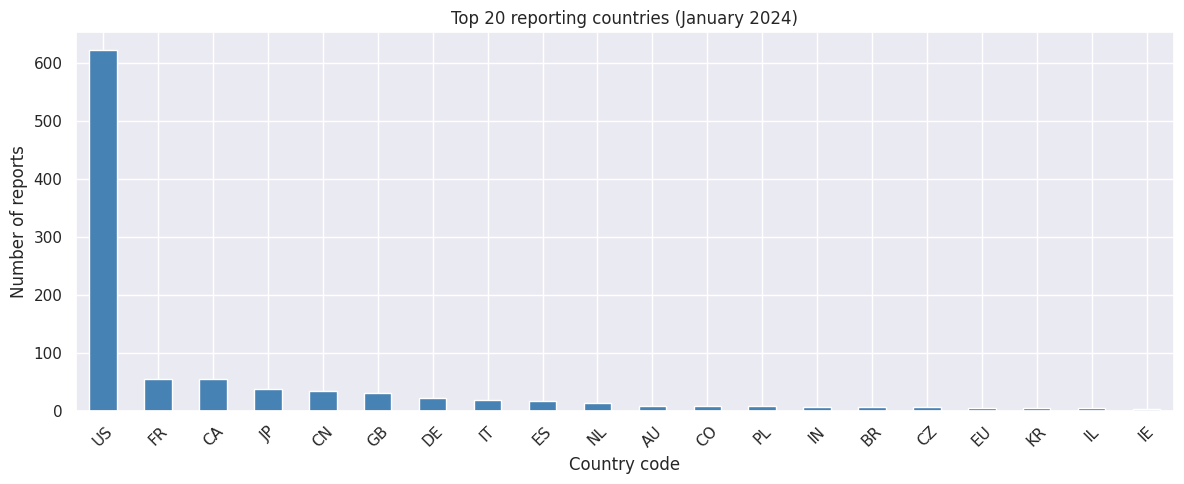

In [8]:
country_counts = df["country"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 5))
country_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Top 20 reporting countries (January 2024)")
ax.set_ylabel("Number of reports")
ax.set_xlabel("Country code")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

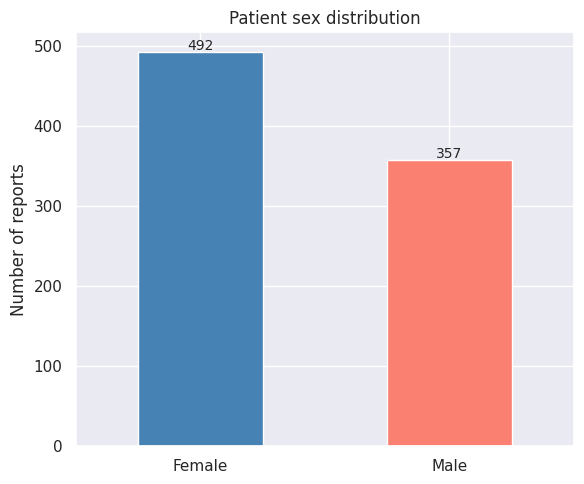

In [9]:
sex_map = {"0": "Unknown", "1": "Male", "2": "Female"}
sex_counts = df["patient_sex"].map(sex_map).value_counts()

fig, ax = plt.subplots(figsize=(6, 5))
sex_counts.plot(kind="bar", ax=ax, color=["steelblue", "salmon", "grey"])
ax.set_title("Patient sex distribution")
ax.set_ylabel("Number of reports")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(int(bar.get_height())),
        ha="center", fontsize=10
    )
plt.tight_layout()
plt.show()

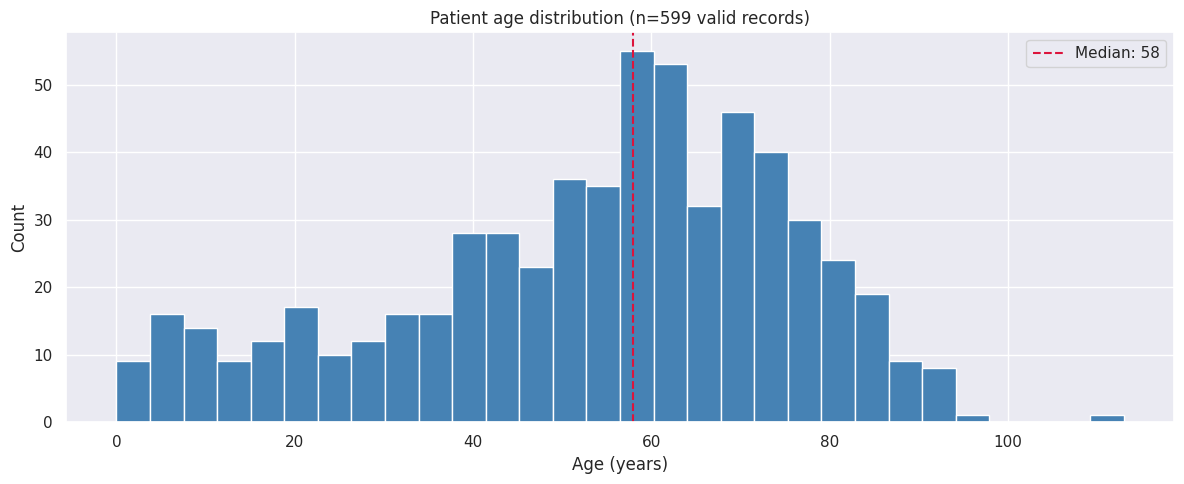

Age stats:
  Min:    0
  Max:    113
  Median: 58
  Mean:   53.5
  Null:   393 records (39.3%)


In [10]:
df["patient_age_num"] = pd.to_numeric(df["patient_age"], errors="coerce")

valid_ages = df["patient_age_num"].dropna()
valid_ages = valid_ages[(valid_ages >= 0) & (valid_ages <= 120)]

fig, ax = plt.subplots()
ax.hist(valid_ages, bins=30, color="steelblue", edgecolor="white")
ax.set_title(f"Patient age distribution (n={len(valid_ages)} valid records)")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Count")
ax.axvline(valid_ages.median(), color="crimson", linestyle="--", label=f"Median: {valid_ages.median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Age stats:")
print(f"  Min:    {valid_ages.min():.0f}")
print(f"  Max:    {valid_ages.max():.0f}")
print(f"  Median: {valid_ages.median():.0f}")
print(f"  Mean:   {valid_ages.mean():.1f}")
print(f"  Null:   {df['patient_age_num'].isnull().sum()} records ({df['patient_age_num'].isnull().mean()*100:.1f}%)")

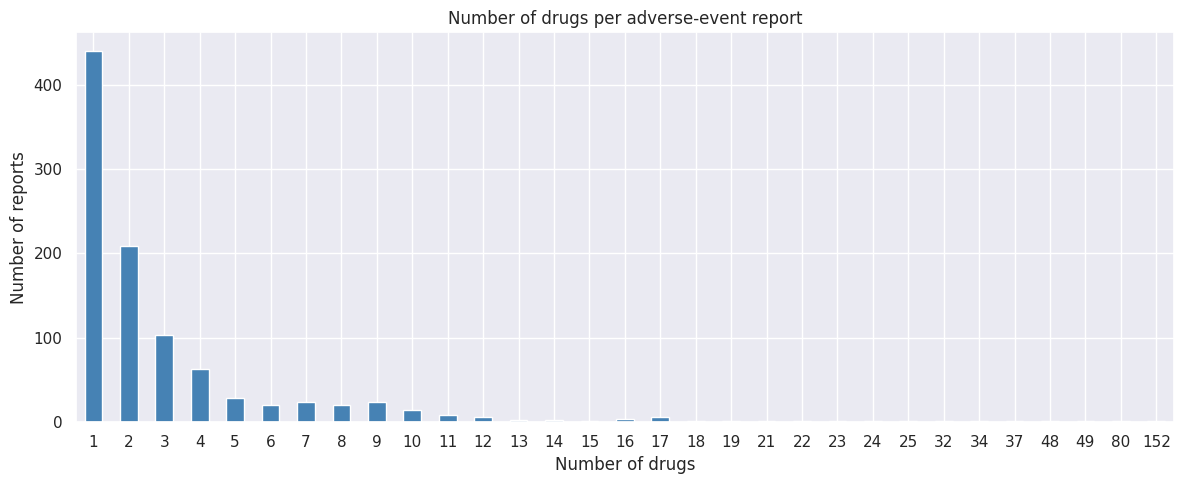

Reports with 1 drug:   440
Reports with 2 drugs:  209
Reports with 3+ drugs: 351
Max drugs in one report: 152


In [11]:
fig, ax = plt.subplots()
df["num_drugs"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of drugs per adverse-event report")
ax.set_xlabel("Number of drugs")
ax.set_ylabel("Number of reports")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(f"Reports with 1 drug:   {(df['num_drugs'] == 1).sum()}")
print(f"Reports with 2 drugs:  {(df['num_drugs'] == 2).sum()}")
print(f"Reports with 3+ drugs: {(df['num_drugs'] >= 3).sum()}")
print(f"Max drugs in one report: {df['num_drugs'].max()}")

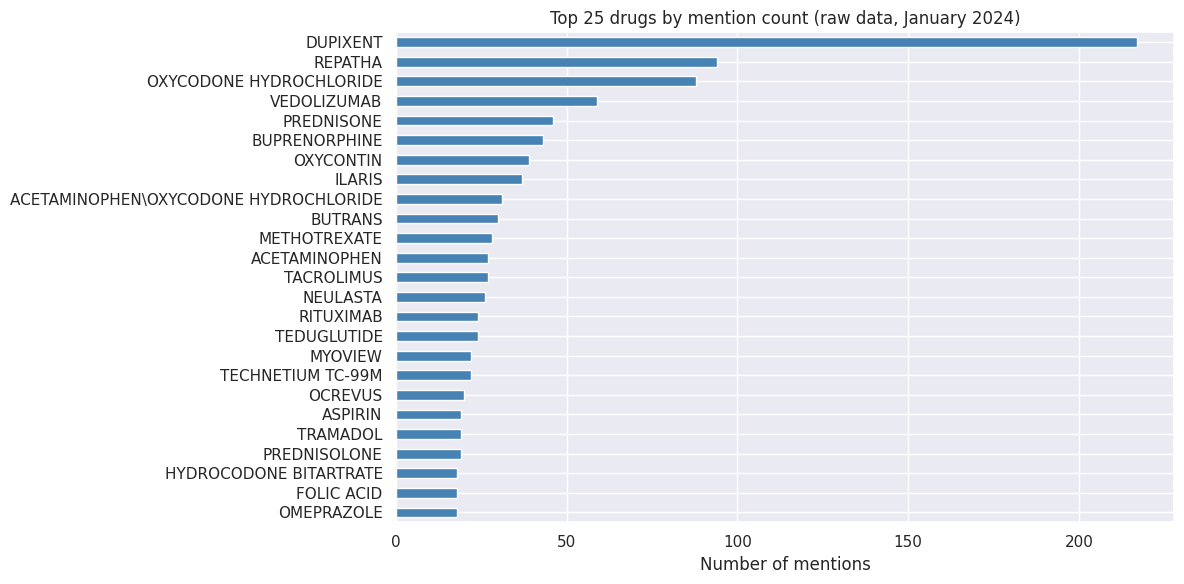


Total drug mentions: 3566
Unique drug names:   1011


In [12]:
drug_names = []
for r in raw_data:
    for drug in r.get("patient", {}).get("drug", []):
        name = drug.get("medicinalproduct", "").strip().upper()
        if name:
            drug_names.append(name)

drug_series = pd.Series(drug_names)
top_drugs = drug_series.value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 6))
top_drugs.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 25 drugs by mention count (raw data, January 2024)")
ax.set_xlabel("Number of mentions")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal drug mentions: {len(drug_names)}")
print(f"Unique drug names:   {drug_series.nunique()}")

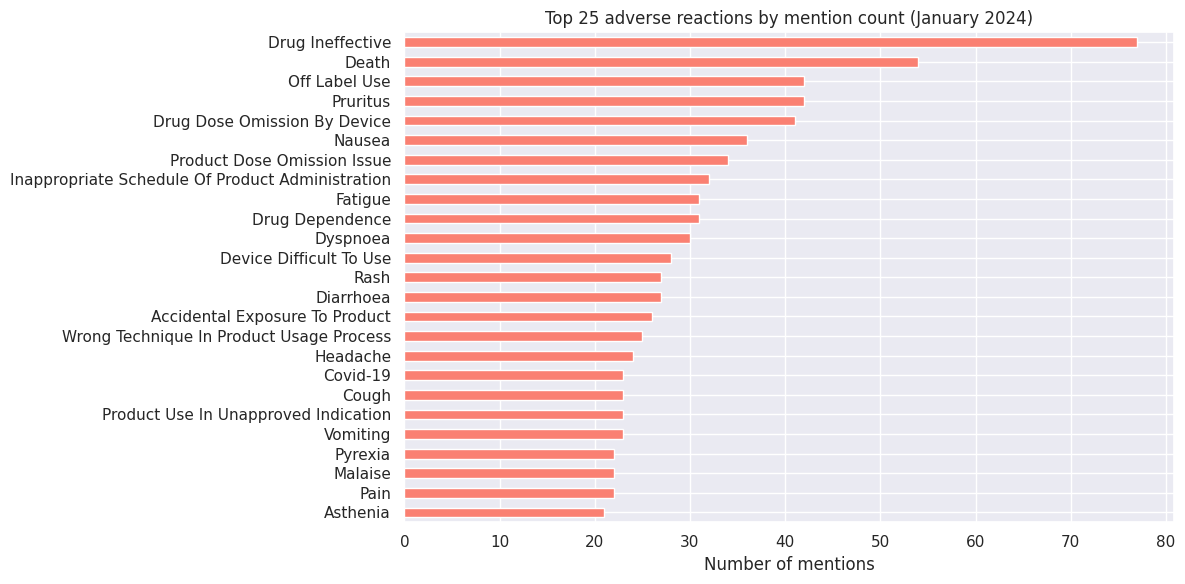


Total reaction mentions: 3202
Unique reaction terms:   1035


In [13]:
reaction_names = []
for r in raw_data:
    for rxn in r.get("patient", {}).get("reaction", []):
        name = rxn.get("reactionmeddrapt", "").strip().title()
        if name:
            reaction_names.append(name)

reaction_series = pd.Series(reaction_names)
top_reactions = reaction_series.value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 6))
top_reactions.plot(kind="barh", ax=ax, color="salmon")
ax.set_title("Top 25 adverse reactions by mention count (January 2024)")
ax.set_xlabel("Number of mentions")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal reaction mentions: {len(reaction_names)}")
print(f"Unique reaction terms:   {reaction_series.nunique()}")

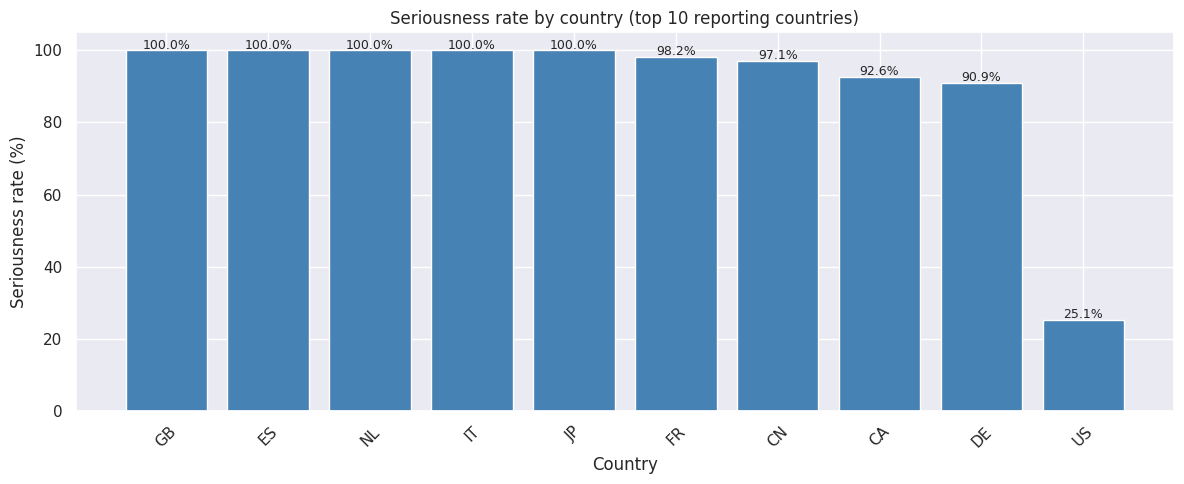

In [14]:
top_countries = df["country"].value_counts().head(10).index.tolist()
country_df = df[df["country"].isin(top_countries)].copy()
country_df["is_serious"] = (country_df["serious"] == "1").astype(int)

seriousness_by_country = (
    country_df.groupby("country")["is_serious"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "seriousness_rate", "count": "total_reports"})
    .sort_values("seriousness_rate", ascending=False)
)
seriousness_by_country["seriousness_rate_pct"] = seriousness_by_country["seriousness_rate"] * 100

fig, ax = plt.subplots()
bars = ax.bar(
    seriousness_by_country.index,
    seriousness_by_country["seriousness_rate_pct"],
    color="steelblue"
)
ax.set_title("Seriousness rate by country (top 10 reporting countries)")
ax.set_ylabel("Seriousness rate (%)")
ax.set_xlabel("Country")
ax.tick_params(axis="x", rotation=45)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center", fontsize=9
    )
plt.tight_layout()
plt.show()

In [15]:
print("=== DATA SUMMARY ===")
print(f"Total reports:            {len(df)}")
print(f"Serious reports:          {(df['serious'] == '1').sum()} ({(df['serious'] == '1').mean()*100:.1f}%)")
print(f"Unique countries:         {df['country'].nunique()}")
print(f"Total drug mentions:      {len(drug_names)}")
print(f"Unique drugs:             {drug_series.nunique()}")
print(f"Total reaction mentions:  {len(reaction_names)}")
print(f"Unique reactions:         {reaction_series.nunique()}")
print(f"Reports with null age:    {df['patient_age_num'].isnull().sum()} ({df['patient_age_num'].isnull().mean()*100:.1f}%)")
print(f"Avg drugs per report:     {df['num_drugs'].mean():.2f}")
print(f"Avg reactions per report: {df['num_reactions'].mean():.2f}")
print()
print("=== WHAT THIS MEANS FOR PHASE 4 ===")
print(f"After exploding drugs:     ~{len(drug_names)} rows in silver_drugs")
print(f"After exploding reactions: ~{len(reaction_names)} rows in silver_reactions")
print(f"silver_adverse_events:     ~{len(df)} rows (one per report)")

=== DATA SUMMARY ===
Total reports:            1000
Serious reports:          521 (52.1%)
Unique countries:         43
Total drug mentions:      3566
Unique drugs:             1011
Total reaction mentions:  3202
Unique reactions:         1035
Reports with null age:    393 (39.3%)
Avg drugs per report:     3.57
Avg reactions per report: 3.20

=== WHAT THIS MEANS FOR PHASE 4 ===
After exploding drugs:     ~3566 rows in silver_drugs
After exploding reactions: ~3202 rows in silver_reactions
silver_adverse_events:     ~1000 rows (one per report)
